- Carrington map: 新的日期对应更小的 longitude; 老日期 -- 大 longitude
    - 所以 back mapping sun time is earlier, but the longitude is larger in carrington

#### From SC to SS

Achieved by Solar Mach

In [29]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
# %matplotlib widget
import sunpy.map
from sunkit_magex import pfss
from sunkit_magex.pfss import tracing
from solarmach import SolarMACH, print_body_list, get_sw_speed, get_gong_map, calculate_pfss_solution
import numpy as np
import astropy.units as u
from astropy.coordinates import Longitude
from solarmach import backmapping_angle
from astropy.coordinates import SkyCoord

# Set the data directory path
DATA_DIR = Path.cwd().parent / 'data'
DATA_DIR = DATA_DIR.resolve()
os.makedirs(DATA_DIR, exist_ok=True)
print(f"Data directory: {DATA_DIR}")
RESULTS_DIR = Path.cwd().parent / 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results directory: {RESULTS_DIR}")

Data directory: /Users/xwu/Library/CloudStorage/OneDrive-Personal/Project/PFSS/data
Results directory: /Users/xwu/Library/CloudStorage/OneDrive-Personal/Project/PFSS/results


In [8]:
date = '2022-3-3 09:44:00'
body_list = ['Solar Orbiter']
coord_sys = 'Carrington'  # 'Stonyhurst' or 'Carrington'

sm = SolarMACH(date=date, body_list=body_list, coord_sys=coord_sys, target_solar_radius=2.5)

No solar wind speeds defined, trying to obtain measurements...


In [9]:
sm.coord_table

,Spacecraft/Body,Carrington longitude (°),Carrington latitude (°),Heliocentric distance (AU),Longitudinal separation to Earth's longitude,Latitudinal separation to Earth's latitude,Vsw,Magnetic footpoint longitude (Carrington)
0,Solar Orbiter,47.808208,-4.146016,0.54677,-6.050819,3.094186,542.21936,72.49629


##### 手动计算 Longitude on SS

(1) Use solar mach tool. No time info

In [60]:
def add_source_surface_coords(coord_table, rss=2.5, diff_rot=True):
    """
    给 SolarMACH 的 coord_table 新增 source surface (rss*Rsun) 的 footpoint lon/lat。
    """
    df = coord_table.copy()

    lon = Longitude(df["Carrington longitude (°)"].to_numpy() * u.deg)
    lat = df["Carrington latitude (°)"].to_numpy() * u.deg
    dist = df["Heliocentric distance (AU)"].to_numpy() * u.AU
    vsw  = df["Vsw"].to_numpy() * (u.km / u.s)

    # alpha = phi(r_sc) - phi(r_target); 目标半径用 rss*Rsun
    alpha = backmapping_angle(dist, rss * u.R_sun, lat, vsw, diff_rot=diff_rot).to(u.deg)

    # phi_target = phi_sc - alpha
    lon_ss = (lon + alpha).wrap_at(360 * u.deg)

    df[f"SS lon @ {rss} Rs (deg)"] = lon_ss.to_value(u.deg)
    df[f"SS lat @ {rss} Rs (deg)"] = (lat.to(u.deg).value)  # 假设纬度不变
    return df

df = add_source_surface_coords(sm.coord_table, rss=2.5)
df[[ "Spacecraft/Body",
      "Carrington longitude (°)", "Carrington latitude (°)",
      "Vsw",
      "SS lon @ 2.5 Rs (deg)", "SS lat @ 2.5 Rs (deg)" ]]


,Spacecraft/Body,Carrington longitude (°),Carrington latitude (°),Vsw,SS lon @ 2.5 Rs (deg),SS lat @ 2.5 Rs (deg)
0,Solar Orbiter,47.808208,-4.146016,542.21936,72.49629,-4.146016


(2) Manually Calc

In [61]:
# 1. 定义常数
# 太阳自转角速度 (Carrington rotation rate)
# 约为 14.713 deg/day, 或者 2.865e-6 rad/s
OMEGA_SUN = 14.713 * u.deg / u.day 
# Source Surface 高度 (通常设为 2.5 个太阳半径)
R_SS = 2.5 * u.R_sun

# 2. 从表格中提取数据
dist_sc = sm.coord_table['Heliocentric distance (AU)'].values * u.AU
lon_sc = sm.coord_table['Carrington longitude (°)'].values * u.deg
vsw = sm.coord_table['Vsw'].values * (u.km / u.s)

# 3. 计算从飞船到 Source Surface 的帕克螺旋经度频移
# 公式: Delta_Phi = Omega * (Distance_SC - R_SS) / Vsw
# 注意：我们要计算的是 footprint，所以是加上这个频移（视坐标系定义而定，通常回推是加经度）
# SolarMACH 内部计算时，Carrington 坐标下，回推通常意味着经度增加（因为太阳自转方向）。

# 计算传输时间 (从 SS 到 SC)
t_travel = (dist_sc - R_SS).to(u.km) / vsw
t_sun = sm.date - t_travel

# 计算经度偏移量
delta_phi = (OMEGA_SUN * t_travel).to(u.deg)

# 4. 计算 Source Surface 上的经度
# 注意：SolarMACH 的 'Magnetic footpoint longitude' 也是通过类似方式算的，
# 只不过它用的距离是 (dist_sc - 0)。
# 我们可以直接重新计算，确保基于 Source Surface。
lon_footpoint_ss = (lon_sc + delta_phi).to(u.deg).value % 360

I think t_obs lat of the SC should be used, but GPT says lat at t_ss should be used. Not sure. Double check later.

sm.coord_table 里 ['Magnetic footpoint longitude (Carrington)'] 与手动计算的 lon at Rss=2.5 相同。

#### From SS to Photosphere

sunkit_magex 的 tracer 会自动双向追踪！
无论 seeds 在 photosphere 还是 source surface，都会追踪到两个边界。

2026-02-03 22:24:30 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-02-03 22:24:30 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


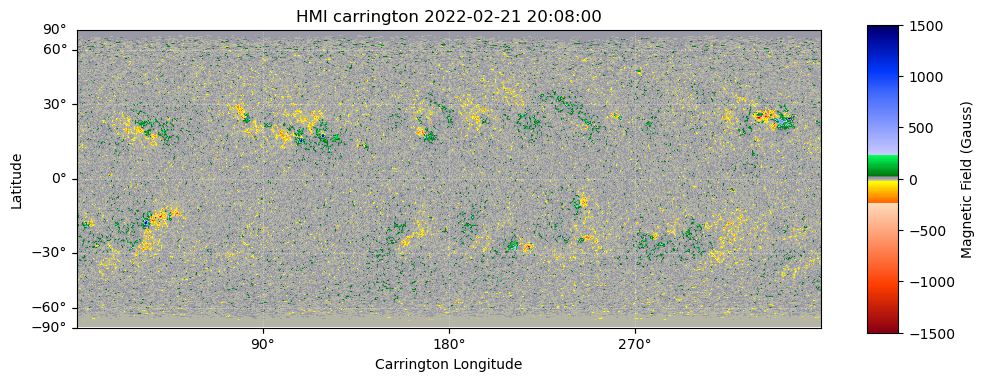

In [ ]:
from sunpy.coordinates import get_earth
# downloaded_files_hmi = [DATA_DIR /'hmi.m_720s.20220303_094800_TAI.3.magnetogram.fits']
# hmi_map = sunpy.map.Map(downloaded_files_hmi)

syn_mag_files = [DATA_DIR/'hmi.synoptic_mr_polfil_720s.2254.Mr_polfil.fits']
hmi_synop = sunpy.map.Map(syn_mag_files[0])

In [ ]:
# # Plot Synoptic map
# # 获取地球在 map 观测时间的位置
# earth_coord = get_earth(hmi_synop.date)
# # 补充 meta 信息
# hmi_synop.meta['dsun_obs'] = earth_coord.radius.to('m').value
# hmi_synop.meta['hgln_obs'] = earth_coord.lon.to('deg').value  
# hmi_synop.meta['hglt_obs'] = earth_coord.lat.to('deg').value

# fig = plt.figure(figsize=(12, 10))
# ax_hmi_synop = fig.add_subplot(111, projection=hmi_synop)
# im = hmi_synop.plot(axes=ax_hmi_synop)
# plt.colorbar(im, label='Magnetic Field (Gauss)', shrink=0.4, aspect=10)

Run PFSS

In [31]:
# PFSS Setting
hmi_synop_resample = hmi_synop.resample([720, 360] * u.pix)
nrho = 25  # Number of radial grid points (higher = more accurate but slower)
rss = 2.5  # Source surface radius in solar radii
pfss_input = pfss.Input(hmi_synop_resample, nrho, rss)
pfss_out = pfss.pfss(pfss_input)

Trace from SS to Solar Surface

In [ ]:
ss_lon = sm.coord_table['Magnetic footpoint longitude (Carrington)'].values* u.deg # np.array([45, 50, 55]) * u.deg  # 经度
ss_lat = sm.coord_table['Carrington latitude (°)'].values* u.deg# np.array([-15, -10, -5]) * u.deg  # 纬度
ss_radius = rss * u.R_sun  # source surface 半径


# 创建 source surface 上的 seeds
# 关键：使用 pfss_out.coordinate_frame，避免 obstime 转换问题
seeds_ss = SkyCoord(
    lon=ss_lon,
    lat=ss_lat,
    radius=np.ones(len(ss_lon)) * ss_radius,
    frame=pfss_out.coordinate_frame
)
print(f"\nseeds_ss frame: {seeds_ss.frame.name}")
# print(f"seeds_ss obstime: {seeds_ss.obstime}")

# 追踪 field lines（自动双向追踪）
tracer_ss = tracing.PerformanceTracer()
flines_ss = tracer_ss.trace(seeds_ss, pfss_out) # radial 方向的 steps 是自动确定的

2026-02-03 22:29:56 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-02-03 22:29:56 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]

seeds_ss frame: heliographic_carrington
seeds_ss obstime: 2022-02-21T20:07:23.000


plot field line

In [34]:
def extract_footpoints(flines):
    """
    从 field lines 中提取 photosphere 和 source surface 上的 footpoints。
    
    Returns
    -------
    solar_footpoints : list of SkyCoord
        Photosphere (1 Rs) 上的坐标
    ss_footpoints : list of SkyCoord  
        Source surface (2.5 Rs) 上的坐标
    polarities : list of int
        磁场极性 (1=向外开放, -1=向内开放, 0=闭合)
    """
    solar_footpoints = []
    ss_footpoints = []
    polarities = []
    
    for fline in flines:
        # 检查 field line 的属性
        polarity = fline.polarity
        polarities.append(polarity)
        
        # solar_footpoint: photosphere 上的位置
        solar_fp = fline.solar_footpoint
        solar_footpoints.append(solar_fp)
        
        # source_surface_footpoint: source surface 上的位置（如果是开放磁力线）
        ss_fp = fline.source_surface_footpoint
        ss_footpoints.append(ss_fp)
        
    return solar_footpoints, ss_footpoints, polarities

# 提取 footpoints
solar_fps, ss_fps, pols = extract_footpoints(flines_ss)

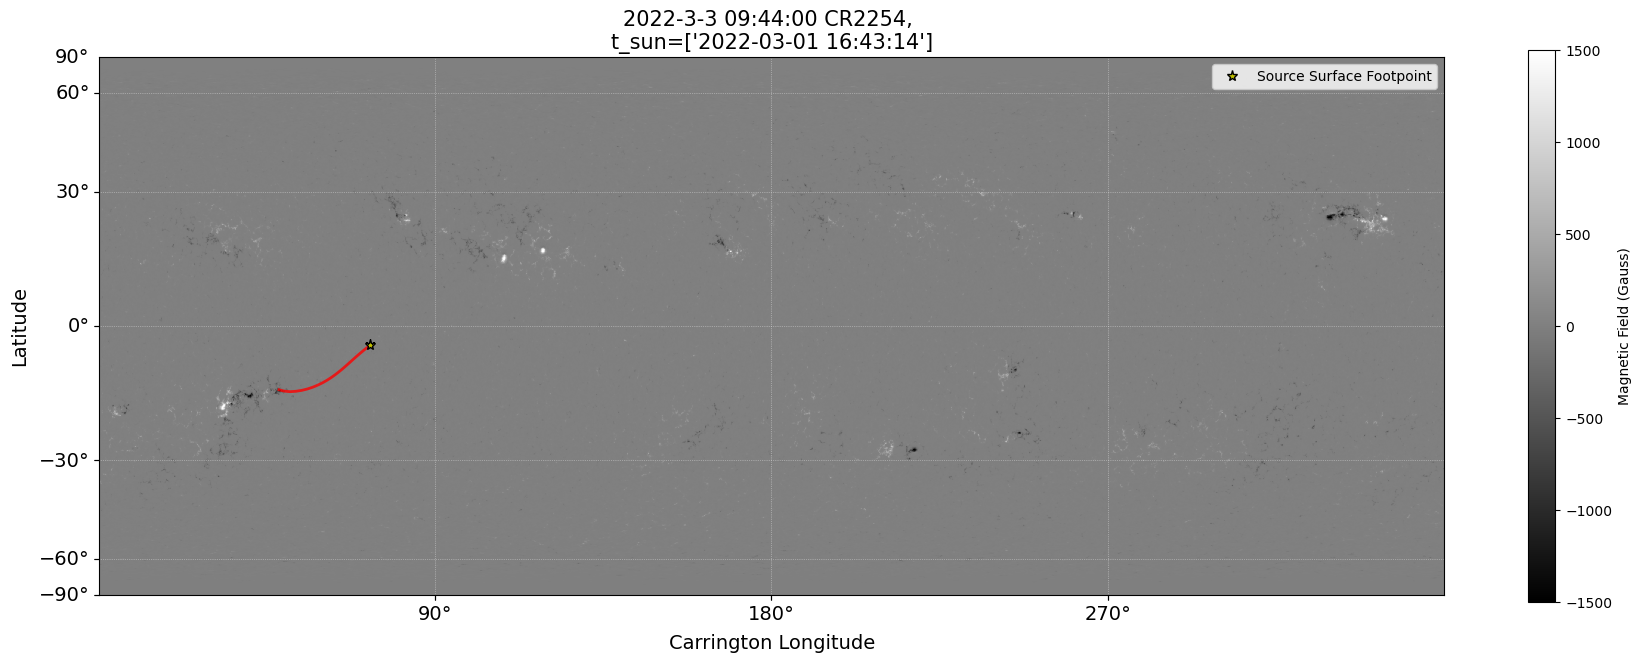

In [ ]:
plt.close()
fig = plt.figure(figsize=(18, 12))
ax = fig.add_subplot(111, projection=hmi_synop)
im = hmi_synop.plot(axes=ax, cmap='gray')
plt.colorbar(im, label='Magnetic Field (Gauss)', shrink=0.5, aspect=20)

# 绘制从 source surface 追踪的 field lines
for fline in flines_ss:
    coords = fline.coords
    lons = coords.lon.to(u.deg).value 
    lats = coords.lat.to(u.deg).value
    px, py = hmi_synop.wcs.world_to_pixel_values(lons, lats)
    
    # 根据极性选择颜色
    if fline.polarity == 1:
        color = 'blue'
        label = 'Open (+)'
    elif fline.polarity == -1:
        color = 'red'
        label = 'Open (-)'
    else:
        color = 'white'
        label = 'Closed'
    
    ax.plot(px, py, color=color, alpha=0.8, linewidth=2)

# 标记 source surface seeds（输入点）
ss_lons = seeds_ss.lon.to(u.deg).value
ss_lats = seeds_ss.lat.to(u.deg).value
ss_px, ss_py = hmi_synop.wcs.world_to_pixel_values(ss_lons, ss_lats)
ax.plot(ss_px, ss_py, 'y*', markersize=8, label='Source Surface Footpoint', 
        markeredgecolor='black', markeredgewidth=1)

# # 标记 photosphere footpoints
# for i, sfp in enumerate(solar_fps):
#     if sfp is not None:
#         fp_lon = sfp.lon.to(u.deg).value
#         fp_lat = sfp.lat.to(u.deg).value
#         fp_px, fp_py = hmi_synop.wcs.world_to_pixel_values(fp_lon, fp_lat)
#         ax.plot(fp_px, fp_py, 'wo', markersize=10, 
#                 markeredgecolor='black', markeredgewidth=2)

ax.set_title(f'{date} CR2254, \nt_sun={t_sun.strftime('%Y-%m-%d %H:%M:%S')}',fontsize=15)
ax.legend(loc='upper right')
ax.tick_params(labelsize=14)
ax.set_ylabel('Latitude', fontsize=14)
ax.set_xlabel('Carrington Longitude', fontsize=14)


plt.tight_layout()
# fig.savefig(f'{RESULTS_DIR}/1Backmapping_ss_to_solarsurface_T(obs)_2022-3-3_094400.png', dpi=300)